## Configuration

In [57]:

# Event metadata
EVENT_NAME = "2019 Ohio Valley Flood"
EVENT_DATE = "2019-02-12"

# Forecast init
FORECAST_INIT = "2019-02-12T00:00:00"
NSTEPS = 12

EXTENT = [-95, -75, 30, 42]


OUTPUT_DIR = "ohio_flood_outputs"
ZARR_STORE = f"{OUTPUT_DIR}/graphcast_flood_forecast_10Day.zarr"

POI_LAT = 38.17
POI_LON = 360 - 85.79  # Convert West longitude to 0-360
POI_LABEL = "Louisville, KY"

## Imports

In [58]:
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch

import earth2studio.run as run
from earth2studio.models.px import GraphCastOperational
from earth2studio.data import ARCO
from earth2studio.io import ZarrBackend

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Load Model & Data Source

In [59]:

package = GraphCastOperational.load_default_package()
prognostic_model = GraphCastOperational.load_model(package)


data = ARCO(cache=True, verbose=True)

print("Model and data source loaded.")

Model and data source loaded.


## Run Deterministic Inference

In [60]:
io = ZarrBackend(ZARR_STORE, backend_kwargs={"overwrite": True})

io = run.deterministic(
    [FORECAST_INIT],
    NSTEPS,
    prognostic_model,
    data,
    io,
)

print(io.root.tree())

2026-04-15 18:36:56.198 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-15 18:36:56.198 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching ARCO data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-15 18:36:56.201 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: z1000 at 2019-02-11T18:00:00
2026-04-15 18:36:56.203 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: t300 at 2019-02-11T18:00:00
2026-04-15 18:36:56.204 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v500 at 2019-02-11T18:00:00
2026-04-15 18:36:56.205 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u500 at 2019-02-11T18:00:00
2026-04-15 18:36:56.206 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: w925 at 2019-02-11T18:00:00
2026-04-15 18:36:56.208 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: t50 at 2019-02-11T18:00:00
2026-04-15 18:36:56.209 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: w600 at 2019-

Fetching ARCO data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-15 18:37:01.445 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: z500 at 2019-02-12T00:00:00
2026-04-15 18:37:01.446 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: t200 at 2019-02-12T00:00:00
2026-04-15 18:37:01.448 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: v150 at 2019-02-12T00:00:00
2026-04-15 18:37:01.449 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: u150 at 2019-02-12T00:00:00
2026-04-15 18:37:01.450 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: w400 at 2019-02-12T00:00:00
2026-04-15 18:37:01.451 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: w200 at 2019-02-12T00:00:00
2026-04-15 18:37:01.452 | DEBUG    | earth2studio.data.arco:fetch_array:297 - Fetching ARCO zarr array for variable: t2m at 2019-0

Fetching ARCO data: 100%|██████████| 82/82 [00:05<00:00, 15.46it/s]


2026-04-15 18:37:07.182 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from ARCO
2026-04-15 18:37:07.320 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:   8%|▊         | 1/13 [00:03<00:41,  3.49s/it]WARNING:absl:Skipping gradient checkpointing for sequence length of 1

Running inference: 100%|██████████| 13/13 [01:29<00:00,  6.88s/it]

2026-04-15 18:38:36.823 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


/
├── lat (721,) float64
├── lead_time (13,) timedelta64
├── lon (1440,) float64
├── msl (1, 13, 721, 1440) float32
├── q100 (1, 13, 721, 1440) float32
├── q1000 (1, 13, 721, 1440) float32
├── q150 (1, 13, 721, 1440) float32
├── q200 (1, 13, 721, 1440) float32
├── q250 (1, 13, 721, 1440) float32
├── q300 (1, 13, 721, 1440) float32
├── q400 (1, 13, 721, 1440) float32
├── q50 (1, 13, 721, 1440) float32
├── q500 (1, 13, 721, 1440) float32
├── q600 (1, 13, 721, 1440) float32
├── q700 (1, 13, 721, 1440) float32
├── q850 (1, 13, 721, 1440) float32
├── q925 (1, 13, 721, 1440) float32
├── t100 (1, 13, 721, 1440) float32
├── t1000 (1, 13, 721, 1440) float32
├── t150 (1, 13, 721, 1440) float32
├── t200 (1, 13, 721, 1440) float32
├── t250 (1, 13, 721, 1440) float32
├── t2m (1, 13, 721, 1440) float32
├── t300 (1, 13, 721, 1440) float32
├── t400 (1, 13, 721, 1440) float32
├── t50 (1, 13, 721, 1440) float32
├── t500 (1, 13, 721, 1440) float32
├── t600 (1, 13, 721, 1440) float32
├── t700 (1, 13, 721, 1440) float32
├── t850 (1, 13, 721, 1440) float32
├── t925 (1, 13, 721, 1440) float32
├── time (1,) datetime64
├── tp06 (1, 13, 721, 1440) float32
├── u100 (1, 13, 721, 1440) float32
├── u1000 (1, 13, 721, 1440) float32
├── u10m (1, 13, 721, 1440) float32
├── u150 (1, 13, 721, 1440) float32
├── u200 (1, 13, 721, 1440) float32
├── u250 (1, 13, 721, 1440) float32
├── u300 (1, 13, 721, 1440) float32
├── u400 (1, 13, 721, 1440) float32
├── u50 (1, 13, 721, 1440) float32
├── u500 (1, 13, 721, 1440) float32
├── u600 (1, 13, 721, 1440) float32
├── u700 (1, 13, 721, 1440) float32
├── u850 (1, 13, 721, 1440) float32
├── u925 (1, 13, 721, 1440) float32
├── v100 (1, 13, 721, 1440) float32
├── v1000 (1, 13, 721, 1440) float32
├── v10m (1, 13, 721, 1440) float32
├── v150 (1, 13, 721, 1440) float32
├── v200 (1, 13, 721, 1440) float32
├── v250 (1, 13, 721, 1440) float32
├── v300 (1, 13, 721, 1440) float32
├── v400 (1, 13, 721, 1440) float32
├── v50 (1, 13, 721, 1440) float32
├── v500 (1, 13, 721, 1440) float32
├── v600 (1, 13, 721, 1440) float32
├── v700 (1, 13, 721, 1440) float32
├── v850 (1, 13, 721, 1440) float32
├── v925 (1, 13, 721, 1440) float32
├── w100 (1, 13, 721, 1440) float32
├── w1000 (1, 13, 721, 1440) float32
├── w150 (1, 13, 721, 1440) float32
├── w200 (1, 13, 721, 1440) float32
├── w250 (1, 13, 721, 1440) float32
├── w300 (1, 13, 721, 1440) float32
├── w400 (1, 13, 721, 1440) float32
├── w50 (1, 13, 721, 1440) float32
├── w500 (1, 13, 721, 1440) float32
├── w600 (1, 13, 721, 1440) float32
├── w700 (1, 13, 721, 1440) float32
├── w850 (1, 13, 721, 1440) float32
├── w925 (1, 13, 721, 1440) float32
├── z100 (1, 13, 721, 1440) float32
├── z1000 (1, 13, 721, 1440) float32
├── z150 (1, 13, 721, 1440) float32
├── z200 (1, 13, 721, 1440) float32
├── z250 (1, 13, 721, 1440) float32
├── z300 (1, 13, 721, 1440) float32
├── z400 (1, 13, 721, 1440) float32
├── z50 (1, 13, 721, 1440) float32
├── z500 (1, 13, 721, 1440) float32
├── z600 (1, 13, 721, 1440) float32
├── z700 (1, 13, 721, 1440) float32
├── z850 (1, 13, 721, 1440) float32
└── z925 (1, 13, 721, 1440) float32

## Helper Functions

In [61]:
def compute_daily_total_precip(io, target_date, init_time, variable="tp06", dt_hours=6):
    """Compute total precipitation (mm) for a specific date.

    Parameters
    ----------
    io : ZarrBackend
        Forecast output.
    target_date : str
        Date to compute total for (e.g., "2019-02-12").
    init_time : str
        Forecast initialization time.
    variable : str
        Precipitation variable name.
    dt_hours : int
        Hours per time step.

    Returns
    -------
    np.ndarray
        2D array of total precipitation (mm) for that day.
    """
    steps_per_day = 24 // dt_hours
    day_start = np.datetime64(target_date)
    init = np.datetime64(init_time)

    first_step = int((day_start - init) / np.timedelta64(dt_hours, "h"))
    first_step = max(first_step, 1)  # skip step 0 (initial condition)

    total = np.zeros_like(io[variable][0, first_step])
    for s in range(first_step, first_step + steps_per_day):
        total += io[variable][0, s] * 1000.0

    return np.clip(total, 0, None)

## Regional Precipitation Map at Event Date

In [62]:
def plot_daily_precip(
    precip_mm,
    io,
    target_date,
    extent,
    init_time,
    poi=None,
    model_name="GraphCast",
    save_path=None,
):
    plt.close("all")

    lon = io["lon"][:]
    lat = io["lat"][:]

    levels = [1, 5, 10, 20, 30, 50, 75, 100]
    cmap = plt.cm.YlOrRd
    norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")

    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(12, 8),
    )

    im = ax.contourf(
        lon, lat, precip_mm,
        levels=levels, cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(), extend="neither",
    )

    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.coastlines(linewidth=0.8)
    ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    ax.set_extent(extent)

    if poi:
        ax.plot(
            poi["lon"] - 360, poi["lat"],
            marker="o", color="lime", markersize=10,
            markeredgecolor="black", markeredgewidth=1.5,
            transform=ccrs.PlateCarree(), zorder=5,
        )
        ax.text(
            poi["lon"] - 360 + 0.3, poi["lat"] + 0.3, poi["label"],
            fontsize=9, fontweight="bold",
            transform=ccrs.PlateCarree(), zorder=5,
        )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, shrink=0.55, pad=0.04, orientation="horizontal")
    cbar.set_label("Total precipitation (mm/day)")

    ax.set_title(
        f"{model_name} | Init: {init_time[:10]} | Date: {target_date}",
        fontsize=11,
    )

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

Saved: ohio_flood_outputs/graphcast_daily_precip_feb12.png


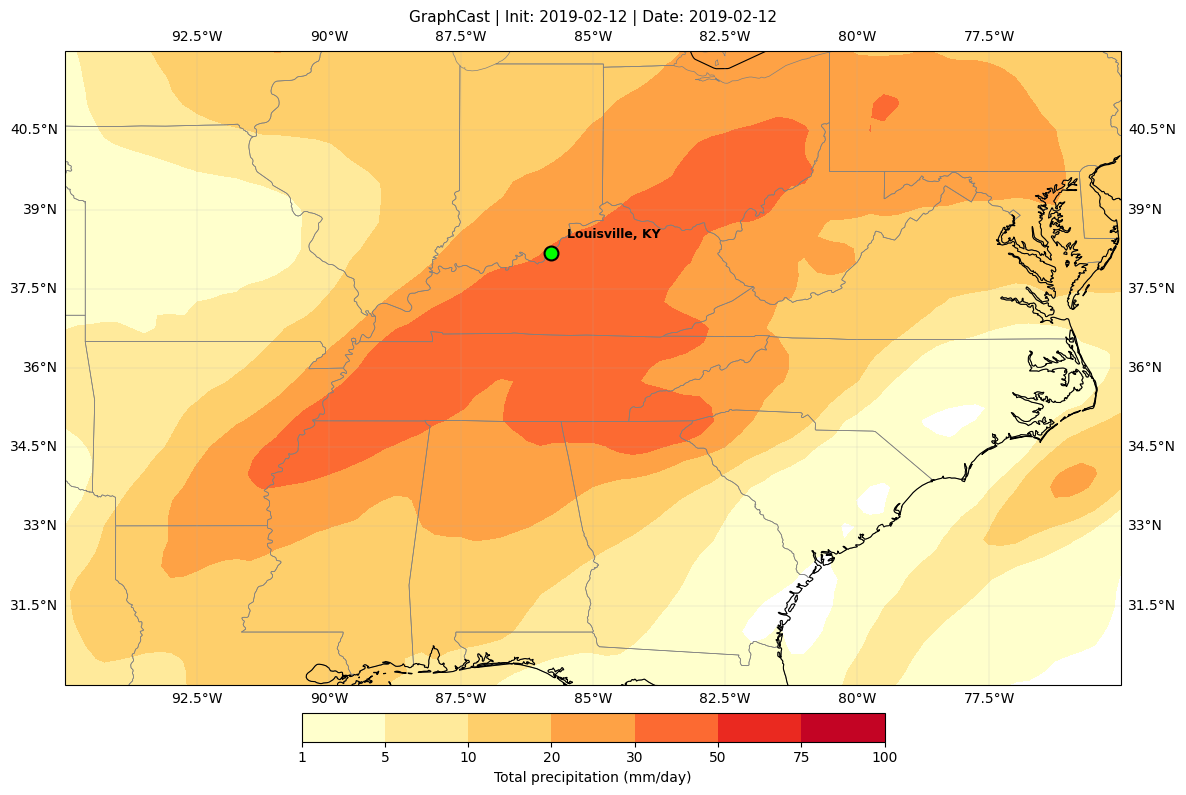

In [63]:
precip_feb12 = compute_daily_total_precip(io, "2019-02-12", FORECAST_INIT)
poi = {"lat": POI_LAT, "lon": POI_LON, "label": POI_LABEL}

plot_daily_precip(
    precip_feb12, io, "2019-02-12", EXTENT, FORECAST_INIT, poi=poi,
    save_path=f"{OUTPUT_DIR}/graphcast_daily_precip_feb12.png",
)

In [64]:
precip_feb12 = compute_daily_total_precip(io, "2019-02-12", FORECAST_INIT)

lat_idx = np.argmin(np.abs(io["lat"][:] - POI_LAT))
lon_idx = np.argmin(np.abs(io["lon"][:] - POI_LON))

print(f"GraphCast total at Louisville on Feb 12: {precip_feb12[lat_idx, lon_idx]:.2f} mm")
print(f"Observed at Louisville on Feb 12: 31.2 mm")

GraphCast total at Louisville on Feb 12: 30.81 mm
Observed at Louisville on Feb 12: 31.2 mm


## Multi-Panel Lead Time Progression

Saved: ohio_flood_outputs/precip_around_event.png


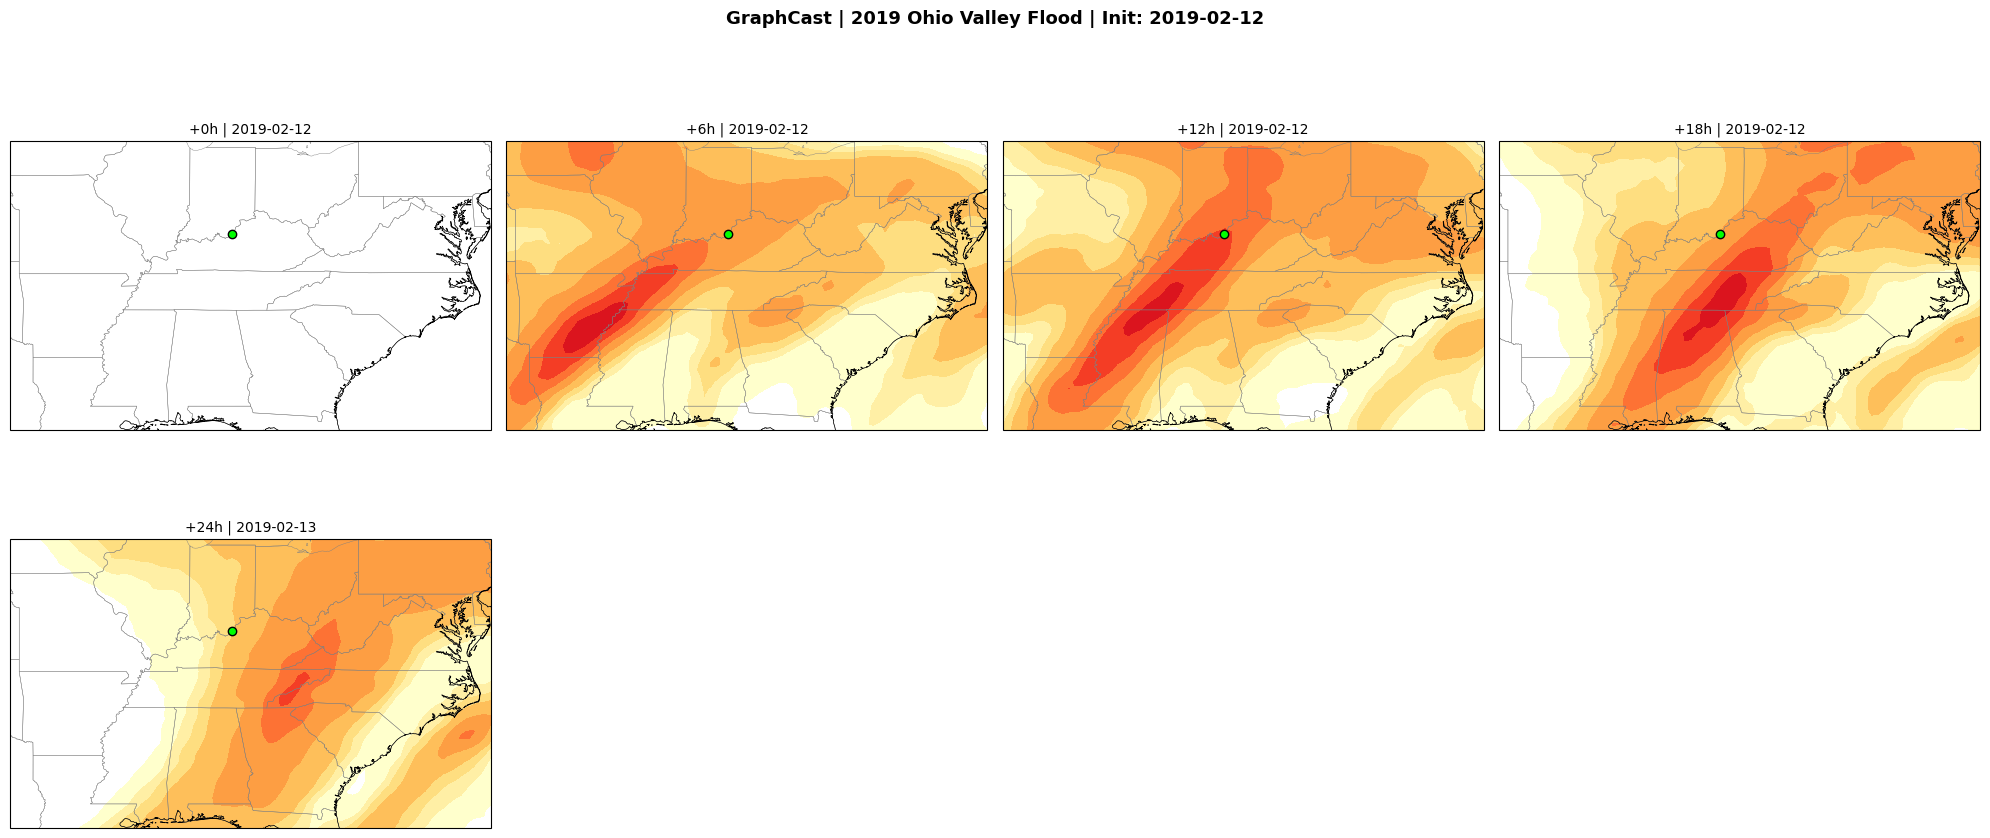

In [29]:
def plot_multi_panel(io, steps, extent, init_time, poi=None, variable="tp06", dt_hours=6, save_path=None):
    """Plot a grid of precipitation maps at specified lead time steps."""
    n = len(steps)
    ncols = min(n, 4)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(5 * ncols, 4.5 * nrows),
    )
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    levels = [0.1, 0.5, 1, 2, 5, 10, 15, 20, 30, 50]
    cmap = plt.cm.YlOrRd
    norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")
    lon = io["lon"][:]
    lat = io["lat"][:]

    for i, step in enumerate(steps):
        ax = axes[i]
        lead_hours = step * dt_hours
        valid_time = np.datetime64(init_time) + np.timedelta64(lead_hours, "h")
        precip_mm = io[variable][0, step] * 1000.0

        ax.contourf(
            lon, lat, precip_mm,
            levels=levels, cmap=cmap, norm=norm,
            transform=ccrs.PlateCarree(), extend="max",
        )
        ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor="gray")
        ax.coastlines(linewidth=0.5)
        ax.set_extent(extent)

        if poi:
            ax.plot(
                poi["lon"] - 360, poi["lat"],
                marker="o", color="lime", markersize=6,
                markeredgecolor="black", markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=5,
            )

        ax.set_title(f"+{lead_hours}h | {str(valid_time)[:10]}", fontsize=10)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"GraphCast | {EVENT_NAME} | Init: {init_time[:10]}",
        fontsize=13, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


# Steps around the event (+/- 24h)
event_step = find_step_for_date(FORECAST_INIT, EVENT_DATE)
nearby_steps = list(range(
    max(event_step - 4, 0),
    min(event_step + 5, NSTEPS + 1),
))

plot_multi_panel(
    io, nearby_steps, EXTENT, FORECAST_INIT,
    poi={"lat": POI_LAT, "lon": POI_LON, "label": POI_LABEL},
    save_path=f"{OUTPUT_DIR}/precip_around_event.png",
)